In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 as cv # OpenCV

# Verify OpenCV version
print(cv.__version__)

4.10.0


In [2]:
# Set visualization size for figures (notebook only)
plt.rcParams['figure.figsize'] = [15, 5] # width, height

#Image loading and visualization

In [3]:
# Image loading
from google.colab import drive
drive.mount('/content/drive')
im1 = cv.imread('/content/drive/MyDrive/Colab Notebooks/pics/left.jpg', cv.IMREAD_GRAYSCALE)
im2 = cv.imread('/content/drive/MyDrive/Colab Notebooks/pics/right.jpg', cv.IMREAD_GRAYSCALE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


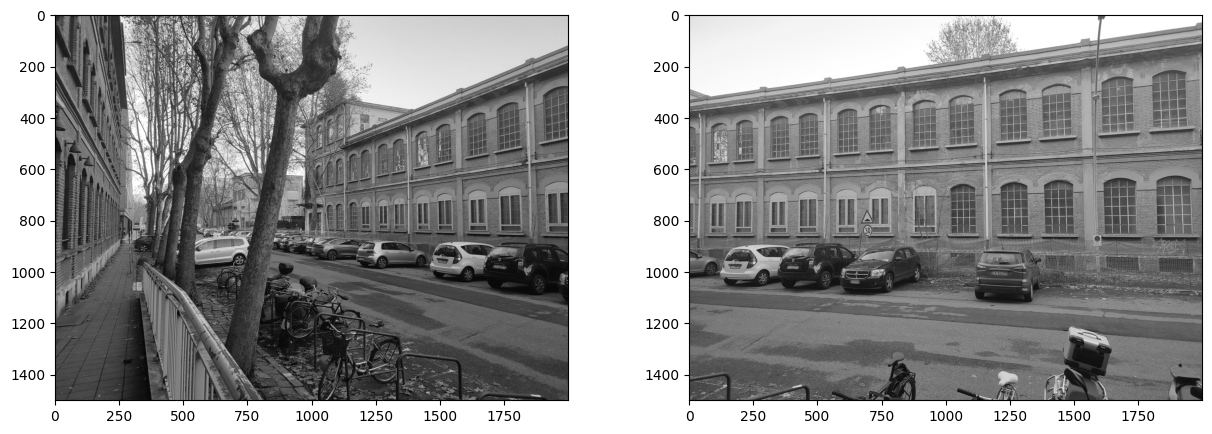

In [4]:
plt.subplot(1,2,1); plt.imshow(im1, cmap='gray');
plt.subplot(1,2,2); plt.imshow(im2, cmap='gray');
plt.show()

The two images are uploaded in a gray scale format, corresponding to the left and right sides of the same landscape.

#*Keypoints extraction*

This keypoints and descriptors from two images are extracted using the SIFT algorithm and then the features are matched using a brute-force matcher with cross-checking for better accuracy.

In [5]:
# Keypoints extraction
sift = cv.SIFT_create()
(kps1, features1) = sift.detectAndCompute(im1, None)
(kps2, features2) = sift.detectAndCompute(im2, None)
# Features matching
bf = cv.BFMatcher.create(crossCheck=True)
matches = bf.match(features1, features2)

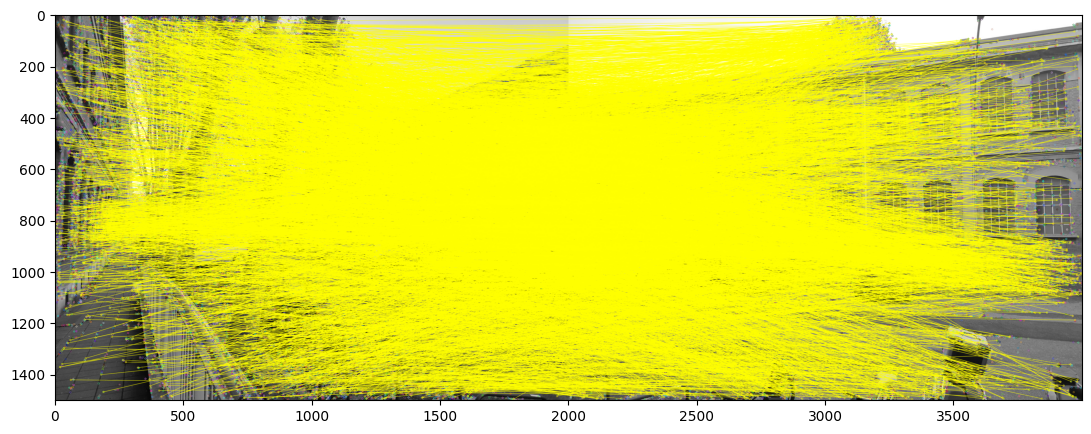

In [6]:
# Visualization of the matches
result = cv.drawMatches(im1, kps1, im2, kps2, matches, None, matchColor=[255,255,0])
plt.imshow(result); plt.show()

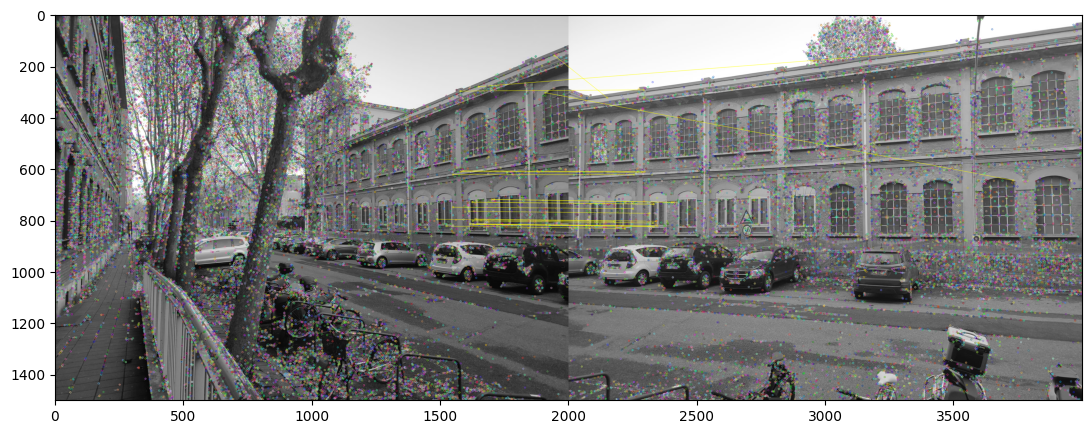

In [7]:
# Visualization of only filtered matches
matches = sorted(matches, key=lambda x:x.distance)
result = cv.drawMatches(im1, kps1, im2, kps2, matches[0:20], None, matchColor=[255,255,0])
plt.imshow(result); plt.show()

This plot is used to visualize the 20 best feature matches between the two images after sorting them based on their match distance.

#*Homography*
\
The homography matrix defines the geometric transformation that maps the second set of points onto the first one. It captures perspective distortions, allowing for alignment between two views of the same scene.

In [8]:
def myHomography(kps1, kps2, matches):
  # Extraction of the coordinates of the keypoints
  dst_pts = np.float32([kps1[m.queryIdx].pt for m in matches]).reshape(-1,1,2) # im1 è l'output
  src_pts = np.float32([kps2[m.trainIdx].pt for m in matches]).reshape(-1,1,2) # im2 è l'input
  # Use the method RANSAC, with 4 random mathces, to determine the homography transformation
  H, _ = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 4.0)
  return H

In [9]:
H = myHomography(kps1, kps2, matches)

In [10]:
print(H)

[[ 9.51393270e-02  7.95663392e-03  1.32853968e+03]
 [-3.64685299e-01  8.27103413e-01  1.23113320e+02]
 [-4.59921245e-04 -1.09675456e-05  1.00000000e+00]]


##Apply the homography to the second image

In [23]:
def myWarp(im, H):
    warped_image = cv.warpPerspective(im, H, (int(1.5*im.shape[1]), im.shape[0]))
    return warped_image

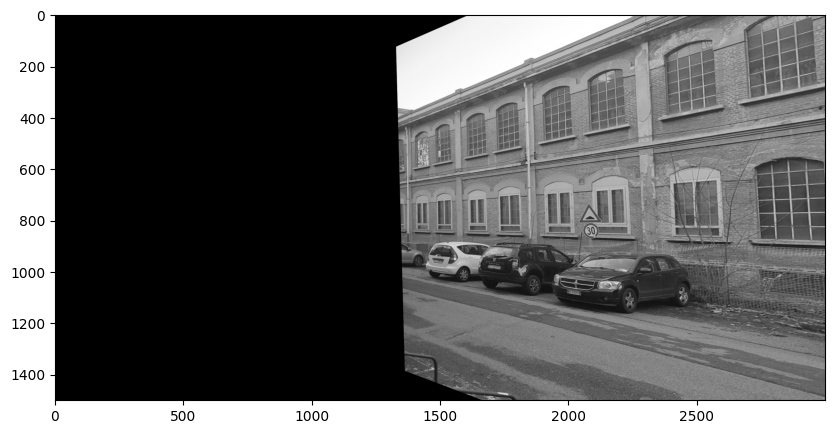

In [24]:
# Apply a perspective warp to stitch the images together
temp = myWarp(im2, H)
plt.imshow(temp, cmap='gray'); plt.show()

By applying the homography to the second image, it is rotated, scaled, and perspective warpped to align it correctly with the left image based on the geometric transformation.

##Integrate the first image in the collage

In [25]:
def myCollage(im_base, im_new):
    im_base[:,0:im_new.shape[1]]= im_new
    collaged_image = im_base
    return collaged_image

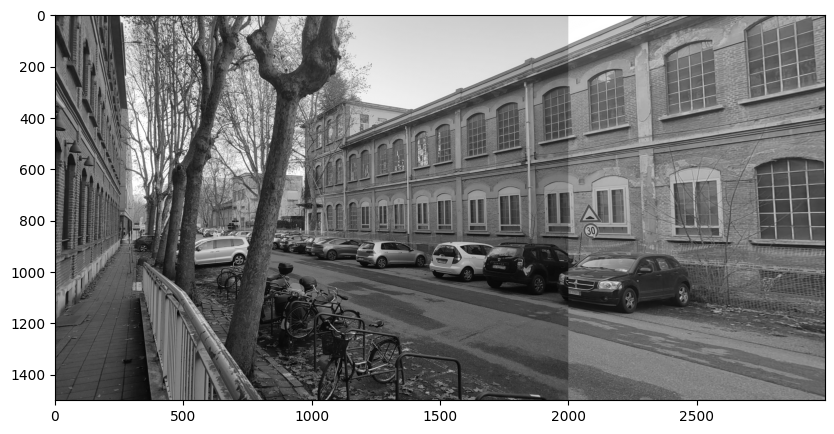

In [26]:
result = myCollage(temp, im1)
plt.imshow(result, cmap='gray'); plt.show()

The final result is a collage image that combines both the left and right images. The right image undergoes the homography transformation to align it correctly with the left image. This process ensures geometric consistency.